In [4]:
from google.colab import files
files.upload()

Saving Metro_Interstate_Traffic_Volume_modified.csv to Metro_Interstate_Traffic_Volume_modified.csv


{'Metro_Interstate_Traffic_Volume_modified.csv': b'date_time,temp,rain_1h,snow_1h,clouds_all,fog_mm,wind_speed_ms,flood_mm,holiday,weather_main,weather_description,day_type,traffic_volume\r\n10/2/12 9:00,288.28,0,0,40,0,2.3,0,,Clouds,scattered clouds,Weekday,5545\r\n10/2/12 10:00,289.36,0,0,75,0,7.45,0,,Clouds,broken clouds,Weekday,4516\r\n10/2/12 11:00,289.58,0,0,90,0,5.68,0,,Clouds,overcast clouds,Weekday,\r\n10/2/12 12:00,290.13,0,0,90,0,1.93,0,,Clouds,overcast clouds,Weekday,5026\r\n10/2/12 13:00,,0,0,75,0,3.56,0,,Clouds,broken clouds,Weekday,4918\r\n10/2/12 14:00,291.72,0,0,1,0,2.41,0,,Clear,sky is clear,Weekday,5181\r\n10/2/12 15:00,293.17,0,0,1,0,1.63,0,,Clear,sky is clear,Weekday,5584\r\n10/2/12 16:00,293.86,0,0,1,0,4.58,0,,Clear,sky is clear,Weekday,\r\n10/2/12 17:00,294.14,0,0,20,0,7.27,0,,Clouds,few clouds,Weekday,5791\r\n10/2/12 18:00,293.1,0,0,20,0,5.29,0,,Clouds,few clouds,Weekday,4770\r\n10/2/12 19:00,290.97,0,0,20,0,4.11,0,,Clouds,few clouds,Weekday,3539\r\n10/2/12 20:0

In [8]:
import pandas as pd ,numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [16]:
df = pd.read_csv("Metro_Interstate_Traffic_Volume_modified.csv")

In [17]:
df.head()

,date_time,temp,rain_1h,snow_1h,clouds_all,fog_mm,wind_speed_ms,flood_mm,holiday,weather_main,weather_description,day_type,traffic_volume
0,10/2/12 9:00,288.28,0.0,0.0,40.0,0.0,2.30,0.0,NaN,Clouds,scattered clouds,Weekday,5545.0
1,10/2/12 10:00,289.36,0.0,0.0,75.0,0.0,7.45,0.0,NaN,Clouds,broken clouds,Weekday,4516.0
2,10/2/12 11:00,289.58,0.0,0.0,90.0,0.0,5.68,0.0,NaN,Clouds,overcast clouds,Weekday,NaN
3,10/2/12 12:00,290.13,0.0,0.0,90.0,0.0,1.93,0.0,NaN,Clouds,overcast clouds,Weekday,5026.0
4,10/2/12 13:00,NaN,0.0,0.0,75.0,0.0,3.56,0.0,NaN,Clouds,broken clouds,Weekday,4918.0


In [18]:
df.shape

(48204, 13)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date_time            48204 non-null  object 
 1   temp                 45794 non-null  float64
 2   rain_1h              45792 non-null  float64
 3   snow_1h              45793 non-null  float64
 4   clouds_all           45794 non-null  float64
 5   fog_mm               48204 non-null  float64
 6   wind_speed_ms        48204 non-null  float64
 7   flood_mm             48202 non-null  float64
 8   holiday              61 non-null     object 
 9   weather_main         48204 non-null  object 
 10  weather_description  48204 non-null  object 
 11  day_type             48204 non-null  object 
 12  traffic_volume       45794 non-null  float64
dtypes: float64(8), object(5)
memory usage: 4.8+ MB


In [ ]:
df.isna().sum()

In [20]:
df.describe()

,temp,rain_1h,snow_1h,clouds_all,fog_mm,wind_speed_ms,flood_mm,traffic_volume
count,45794.000000,45792.000000,45793.000000,45794.000000,48204.000000,48204.000000,48202.000000,45794.000000
mean,281.219070,0.345503,0.000230,49.406931,8.568209,5.396802,0.785051,3261.366991
std,13.378092,45.953150,0.008367,39.021861,42.113011,3.548947,8.152681,1987.139170
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.000000
25%,272.180000,0.000000,0.000000,1.000000,0.000000,2.820000,0.000000,1195.000000
50%,282.480000,0.000000,0.000000,64.000000,0.000000,5.050000,0.000000,3380.000000
75%,291.830000,0.000000,0.000000,90.000000,0.000000,7.040000,0.000000,4936.000000
max,310.070000,9831.300000,0.510000,100.000000,499.260000,24.980000,407.930000,7280.000000


In [21]:
print((df["temp"] < 200).sum(), (df["rain_1h"] > 100).sum())

10 1


In [22]:
df["holiday"].value_counts(dropna=False)

,count
holiday,
NaN,48143
Labor Day,7
Christmas Day,6
Thanksgiving Day,6
Martin Luther King Jr Day,6
New Years Day,6
Veterans Day,5
Columbus Day,5
Memorial Day,5


In [23]:
df["day_type"].value_counts(dropna=False)

,count
day_type,
Weekday,34501
Weekend,13703


In [24]:
df["weather_main"].value_counts(dropna=False)

,count
weather_main,
Clouds,15164
Clear,13391
Mist,5950
Rain,5672
Snow,2876
Drizzle,1821
Haze,1360
Thunderstorm,1034
Fog,912


In [25]:
df.groupby("weather_main")["weather_description"].nunique()

,weather_description
weather_main,
Clear,2
Clouds,4
Drizzle,4
Fog,1
Haze,1
Mist,1
Rain,7
Smoke,1
Snow,7


In [26]:
df["weather_description"].nunique()

38

In [27]:
df["date_time"].head(10)

,date_time
0,10/2/12 9:00
1,10/2/12 10:00
2,10/2/12 11:00
3,10/2/12 12:00
4,10/2/12 13:00
5,10/2/12 14:00
6,10/2/12 15:00
7,10/2/12 16:00
8,10/2/12 17:00
9,10/2/12 18:00


In [28]:
pd.to_datetime(df["date_time"], format="%m/%d/%y %H:%M").agg(["min", "max"])

,date_time
min,2012-10-02 09:00:00
max,2018-09-30 23:00:00


In [29]:
df.groupby(pd.to_datetime(df["date_time"], format="%m/%d/%y %H:%M").dt.hour)["traffic_volume"].mean().round()

,traffic_volume
date_time,
0,839.0
1,517.0
2,389.0
3,372.0
4,702.0
5,2086.0
6,4153.0
7,4753.0
8,4579.0


In [30]:
df.groupby("day_type")["traffic_volume"].mean().round()

,traffic_volume
day_type,
Weekday,3538.0
Weekend,2564.0


In [31]:
df.groupby(df["holiday"].notna())["traffic_volume"].mean().round()

,traffic_volume
holiday,
False,3264.0
True,877.0


In [32]:
df.corr(numeric_only=True)["traffic_volume"].round(3)

,traffic_volume
temp,0.130
rain_1h,0.005
snow_1h,0.002
clouds_all,0.068
fog_mm,-0.049
wind_speed_ms,-0.010
flood_mm,-0.018
traffic_volume,1.000


In [33]:
df = df.dropna(subset=["traffic_volume"])
print(df.shape)

(45794, 13)


In [34]:
df.loc[df["temp"] < 200, "temp"] = np.nan
df.loc[df["rain_1h"] > 100, "rain_1h"] = np.nan

In [35]:
cols = ["temp", "rain_1h", "snow_1h", "clouds_all", "flood_mm"]
for c in cols:
    df[c] = df[c].fillna(df[c].median())

print(df[cols].isna().sum())

temp          0
rain_1h       0
snow_1h       0
clouds_all    0
flood_mm      0
dtype: int64


In [36]:
df["is_holiday"] = df["holiday"].notna().astype(int)
print(df["is_holiday"].value_counts())

is_holiday
0    45736
1       58
Name: count, dtype: int64


In [37]:
df["date_time"] = pd.to_datetime(df["date_time"], format="%m/%d/%y %H:%M")
df["hour"] = df["date_time"].dt.hour
df["month"] = df["date_time"].dt.month
df["dayofweek"] = df["date_time"].dt.dayofweek
df["year"] = df["date_time"].dt.year
print(df[["date_time", "hour", "month", "dayofweek", "year"]].head())

            date_time  hour  month  dayofweek  year
0 2012-10-02 09:00:00     9     10          1  2012
1 2012-10-02 10:00:00    10     10          1  2012
3 2012-10-02 12:00:00    12     10          1  2012
4 2012-10-02 13:00:00    13     10          1  2012
5 2012-10-02 14:00:00    14     10          1  2012


In [38]:
df = df.drop(columns=["date_time", "holiday", "weather_description"])
print(df.columns.tolist())

['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'fog_mm', 'wind_speed_ms', 'flood_mm', 'weather_main', 'day_type', 'traffic_volume', 'is_holiday', 'hour', 'month', 'dayofweek', 'year']


In [39]:
df = pd.get_dummies(df, columns=["weather_main", "day_type"], drop_first=True)
print(df.shape)

(45794, 24)


In [40]:
X = df.drop(columns="traffic_volume")
y = df["traffic_volume"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(36635, 23) (9159, 23)


In [41]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_lr)))
print("R2:", r2_score(y_test, pred_lr))

MAE: 1571.1730361141263
RMSE: 1790.1834945800847
R2: 0.1928623149174863


In [42]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf)))
print("R2:", r2_score(y_test, pred_rf))

MAE: 237.70835899115622
RMSE: 427.0552285357716
R2: 0.954067443868268


In [43]:
pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(8).round(3)

,0
hour,0.825
dayofweek,0.062
day_type_Weekend,0.047
temp,0.023
wind_speed_ms,0.012
month,0.010
year,0.007
clouds_all,0.005


<Axes: >

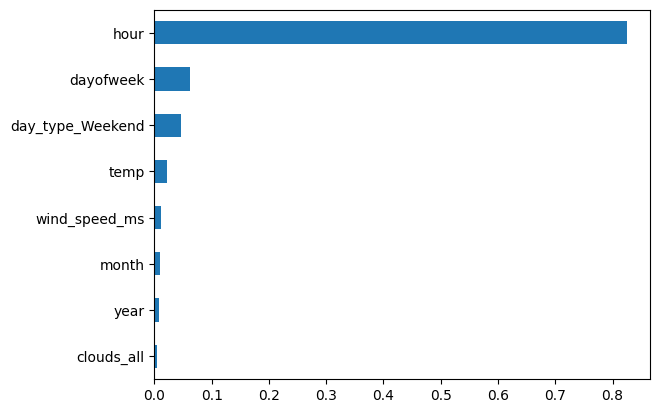

In [44]:
pd.Series(rf.feature_importances_, index=X.columns).sort_values().tail(8).plot(kind="barh")

In [45]:
lr_train = r2_score(y_train, lr.predict(X_train))
lr_test = r2_score(y_test, lr.predict(X_test))

rf_train = r2_score(y_train, rf.predict(X_train))
rf_test = r2_score(y_test, rf.predict(X_test))

print("Linear -> train:", round(lr_train, 3), " test:", round(lr_test, 3), " gap:", round(lr_train - lr_test, 3))
print("Random Forest -> train:", round(rf_train, 3), " test:", round(rf_test, 3), " gap:", round(rf_train - rf_test, 3))

Linear -> train: 0.192  test: 0.193  gap: -0.001
Random Forest -> train: 0.993  test: 0.954  gap: 0.039


In [46]:
from sklearn.model_selection import cross_val_score
print(cross_val_score(rf, X, y, cv=5, scoring="r2").round(3))

[0.932 0.927 0.91  0.95  0.926]


In [47]:
!pip install gradio

In [48]:
def predict_traffic(hour, dayofweek, is_holiday, temp_c, weather):
    row = pd.DataFrame(0.0, index=[0], columns=X.columns)

    for c in ["rain_1h", "snow_1h", "clouds_all", "fog_mm", "wind_speed_ms", "flood_mm", "month", "year"]:
        row[c] = X_train[c].median()

    row["hour"] = hour
    row["dayofweek"] = dayofweek
    row["is_holiday"] = int(is_holiday)
    row["temp"] = temp_c + 273.15
    row["day_type_Weekend"] = 1 if dayofweek >= 5 else 0
    if weather != "Clear":
        row["weather_main_" + weather] = 1

    return rf.predict(row)[0]

print(predict_traffic(17, 2, False, 15, "Clear"))

5603.55


In [49]:
import gradio as gr

days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weathers = ["Clear", "Clouds", "Drizzle", "Fog", "Haze", "Mist", "Rain", "Smoke", "Snow", "Squall", "Thunderstorm"]

def run(hour, day, holiday, temp_c, weather):
    result = predict_traffic(hour, days.index(day), holiday, temp_c, weather)
    return f"{round(result)} cars per hour"

page = gr.Interface(
    fn=run,
    inputs=[
        gr.Slider(0, 23, step=1, value=8, label="Hour"),
        gr.Dropdown(days, value="Monday", label="Day of week"),
        gr.Checkbox(label="Public holiday"),
        gr.Number(value=15, label="Temperature (C)"),
        gr.Dropdown(weathers, value="Clear", label="Weather"),
    ],
    outputs=gr.Textbox(label="Predicted traffic volume"),
    title="Traffic Volume Predictor",
)

page.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://631cb08802b5e0445e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
